This is a trial run. I just want to define my main functions here (Gaussian elimination, random circuit generation and evolution, entropy calculation, etc.) and then test it on small systems. Then I will scale things up in another folder. 

2 separate functions for packing and rank calculations

#TWO SEPARATE FUNCTIONS FOR PACKING AND RANK CALCULATION, BOTH OPTIMIZED WITH NUMBA

import numpy as np
from numba import njit
import time

# --- 1. The Matrix Packer ---
@njit
def pack_binary_matrix(binary_matrix):
    """
    Compresses an (N x M) binary matrix into an (N x W) uint64 matrix.
    Every 64 columns of the original matrix become 1 column of 64-bit integers.
    """
    rows, cols = binary_matrix.shape
    # Calculate how many 64-bit words we need per row (ceiling division)
    words = (cols + 63) // 64 
    
    # Initialize the compressed matrix with 64-bit unsigned integers
    packed = np.zeros((rows, words), dtype=np.uint64)
    
    """Iterate through the original binary matrix and set the corresponding bits in the packed matrix. We do this by 
    calculating the word index and bit index for each 1 in the original matrix, then using bitwise OR with a bit mask to set the bit in the packed matrix.
    The bitmask is created by left-shifting 1 by the bit index by an amount equal to the bit index, and we ensure that the shift is done on a 64-bit type to prevent overflow.
    The bitmask is then ORed with the current value in the packed matrix at the appropriate word index to set the bit corresponding to the 1 in the original matrix.
    We only process the 1s to save time, as the 0s are already"""
    for r in range(rows):
        for c in range(cols):
            if binary_matrix[r, c] == 1: 
                word_idx = c // 64 #extract the word index
                bit_idx = c % 64 #extract the bit index within that word

                # Force the 1 to be a 64-bit type before shifting to prevent overflow. 
                bit_mask = np.uint64(1) << np.uint64(bit_idx)
                packed[r, word_idx] |= bit_mask #manually set the bit using bitwise OR for each 1 in the original matrix
                
    return packed

# --- 2. The Ultra-Fast Rank Solver ---
@njit
def gf2_rank(packed_matrix, num_cols):
    """
    Computes the GF(2) rank directly on the packed uint64 memory blocks.
    Utilizes the upper-triangular shortcut to cut mathematical operations in half.
    """
    mat = packed_matrix.copy()
    rows, words = mat.shape
    rank = 0
    
    for col in range(num_cols):
        # Locate the exact integer and the exact bit within it for the current column
        word_idx = col // 64
        bit_idx = col % 64
        
        # 1. Pivot search (Optimized: Only search from the current rank downwards)
        pivot_row = -1
        for r in range(rank, rows):
            # Shift the target bit to the 0th position and mask it with 1
            if (mat[r, word_idx] >> np.uint64(bit_idx)) & np.uint64(1):
                pivot_row = r
                break
                
        if pivot_row == -1:
            continue
            
        # 2. Row swap
        if pivot_row != rank:
            for w in range(words):
                temp = mat[rank, w]
                mat[rank, w] = mat[pivot_row, w]
                mat[pivot_row, w] = temp
                
        # 3. Row elimination via XOR 
        # (Optimized: Only eliminate strictly BELOW the pivot to form Row Echelon Form)
        for r in range(rank + 1, rows):
            if (mat[r, word_idx] >> np.uint64(bit_idx)) & np.uint64(1):
                # The Hardware Magic: XORing a single word processes 64 bits simultaneously
                for w in range(words):
                    mat[r, w] ^= mat[rank, w]
                    
        rank += 1
        if rank == rows:
            break
            
    return rank

# ==========================================
# BENCHMARK TEST (10000 x 10000)
# ==========================================
if __name__ == "__main__":
    N = 10000
    print(f"Generating random {N} x {N} binary matrix...")
    # Use uint8 for the initial generation to save RAM before packing
    binary_matrix = np.random.randint(0, 2, (N, 2 * N), dtype=np.uint8)
    
    # Pack the matrix
    t0 = time.time()
    packed_mat = pack_binary_matrix(binary_matrix)
    rank = gf2_rank(packed_mat, num_cols=2 *N)
    t1 = time.time()
    
    print(f"Rank: {rank}")
    print(f"Rank calculation time: {t1 - t0:.4f} seconds.")

One single function for both packing and rank calculation, uses matrix packing and passes the output (packed matrix) to the rank calculator to calculate the rank. As of March 23, this is faster.

In [100]:
#ONE SINGLE FUNCTION FOR BOTH PACKING AND RANK CALCULATION, OPTIMIZED WITH NUMBA. THIS DOES NOT PRESERVE THE ORIGINAL MATRIX!!!!!!!!!!!!!

import numpy as np
from numba import njit, test
import time

# --- 1. The Matrix Packer ---
@njit
def rank_binary_matrix(binary_matrix):
    """
    Compresses an (N x M) binary matrix into an (N x W) uint64 matrix.
    Every 64 columns of the original matrix become 1 column of 64-bit integers.
    """
    rows, cols = binary_matrix.shape
    # Calculate how many 64-bit words we need per row (ceiling division)
    words = (cols + 63) // 64 
    
    # Initialize the compressed matrix with 64-bit unsigned integers
    packed = np.zeros((rows, words), dtype=np.uint64)
    
    """Iterate through the original binary matrix and set the corresponding bits in the packed matrix. We do this by 
    calculating the word index and bit index for each 1 in the original matrix, then using bitwise OR with a bit mask to set the bit in the packed matrix.
    The bitmask is created by left-shifting 1 by the bit index by an amount equal to the bit index, and we ensure that the shift is done on a 64-bit type to prevent overflow.
    The bitmask is then ORed with the current value in the packed matrix at the appropriate word index to set the bit corresponding to the 1 in the original matrix.
    We only process the 1s to save time, as the 0s are already"""
    for r in range(rows):
        for c in range(cols):
            if binary_matrix[r, c] == 1: 
                word_idx = c // 64 #extract the word index
                bit_idx = c % 64 #extract the bit index within that word

                # Force the 1 to be a 64-bit type before shifting to prevent overflow. 
                bit_mask = np.uint64(1) << np.uint64(bit_idx)
                packed[r, word_idx] |= bit_mask #manually set the bit using bitwise OR for each 1 in the original matrix
                


    """
    Computes the GF(2) rank directly on the packed uint64 memory blocks.
    Utilizes the upper-triangular shortcut to cut mathematical operations in half.
    """
    rows, words = packed.shape
    rank = 0
    
    for col in range(cols):
        # Locate the exact integer and the exact bit within it for the current column
        word_idx = col // 64
        bit_idx = col % 64
        
        # 1. Pivot search (Optimized: Only search from the current rank downwards)
        pivot_row = -1
        for r in range(rank, rows):
            # Shift the target bit to the 0th position and mask it with 1
            if (packed[r, word_idx] >> np.uint64(bit_idx)) & np.uint64(1):
                pivot_row = r
                break
                
        if pivot_row == -1:
            continue
            
        # 2. Row swap
        if pivot_row != rank:
            for w in range(words):
                temp = packed[rank, w]
                packed[rank, w] = packed[pivot_row, w]
                packed[pivot_row, w] = temp
                
        # 3. Row elimination via XOR 
        # (Optimized: Only eliminate strictly BELOW the pivot to form Row Echelon Form)
        for r in range(rank + 1, rows):
            if (packed[r, word_idx] >> np.uint64(bit_idx)) & np.uint64(1):
                # The Hardware Magic: XORing a single word processes 64 bits simultaneously
                for w in range(words):
                    packed[r, w] ^= packed[rank, w]
                    
        rank += 1
        if rank == rows:
            break
            
    return rank

## ==========================================
# TESTING
## ==========================================
test1 = np.array([[1, 0],
                 [0, 1]])
print("\nTest Matrix 1:")
print(test1 )
print("Calculated Rank:", rank_binary_matrix(test1))

test2 = np.array([[1, 0, 1],
                 [0, 1, 1], 
                   [1, 1, 0]])
print("\nTest Matrix 2:")
print(test2 )
print("Calculated Rank:", rank_binary_matrix(test2))

test3 = np.array([[1, 0],
                 [1, 0], 
                [0, 0]])
print("\nTest Matrix 3:")
print(test3 )
print("Calculated Rank:", rank_binary_matrix(test3))

test4 = np.array([[1, 1, 0, 0],
                 [0, 1, 1, 0],
                 [0, 0, 1, 1],
                 [1, 0, 0, 1]])
print("\nTest Matrix 4:")
print(test4 )
print("Calculated Rank:", rank_binary_matrix(test4))

test5 = np.array([[1]])
print("\nTest Matrix 5:")
print(test5 )
print("Calculated Rank:", rank_binary_matrix(test5))

test6 = np.zeros((10, 10))
print("\nTest Matrix 6 (10x10 zeros):")
print(test6 )
print("Calculated Rank:", rank_binary_matrix(test6))

test7 = np.ones((7, 9))
print("\nTest Matrix 7 (7x9 ones):")
print(test7 )
print("Calculated Rank:", rank_binary_matrix(test7))
    




Test Matrix 1:
[[1 0]
 [0 1]]
Calculated Rank: 2

Test Matrix 2:
[[1 0 1]
 [0 1 1]
 [1 1 0]]
Calculated Rank: 2

Test Matrix 3:
[[1 0]
 [1 0]
 [0 0]]
Calculated Rank: 1

Test Matrix 4:
[[1 1 0 0]
 [0 1 1 0]
 [0 0 1 1]
 [1 0 0 1]]
Calculated Rank: 3

Test Matrix 5:
[[1]]
Calculated Rank: 1

Test Matrix 6 (10x10 zeros):
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
Calculated Rank: 0

Test Matrix 7 (7x9 ones):
[[1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1.]]
Calculated Rank: 1


Entropy calculator (simple)

In [101]:
import numpy as np

def calculate_entropy(stabilizer, n_cut):
    """
    Calculates the entanglement entropy for a given stabilizer matrix and cut.
    """
    if n_cut > stabilizer.shape[0]:
        raise ValueError("n_cut cannot be greater than the number of qubits in the stabilizer.")
    L = stabilizer.shape[1] // 2
    print(f"Stabilizer shape: {stabilizer.shape}, L: {L}, n_cut: {n_cut}")  
    
    # 1. Grab X columns for qubits 0 to n-1
    # 2. Grab Z columns for qubits 0 to n-1 (offset by L)
    # We use np.hstack to join them into an L x 2n matrix
    sub_A = np.hstack([stabilizer[:, :n_cut], stabilizer[:, L : L+n_cut]])
    print(f"Submatrix: \n {sub_A} \n")

    rank = rank_binary_matrix(sub_A)
    print(f"Rank: {rank}")

    return rank - n_cut



Test of the entropy calculation follow. 

We first have the Bell state

In [102]:
import numpy as np
from numba import njit
import stim


# 1. Create the 'Instruction' set
circuit = stim.Circuit()
circuit.append("H", [0])
circuit.append("CNOT", [0, 1])


# 2. Create the 'Simulator' (The thing that holds the state)
sim = stim.TableauSimulator()

# 3. Feed the instructions to the simulator
sim.do(circuit)
hasattr(sim, "current_tableau")
# 4. Peek at the Binary Check Matrix (Tableau)
# We use current_inverse_tableau because it gives the 'stabilizers' directly
# Pull the internal Heisenberg state and invert it to get the Schrödinger state
tableau = sim.current_inverse_tableau() ** -1

# 1. to_numpy() returns 6 blocks: 
# (X-to-X, X-to-Z, Z-to-X, Z-to-Z, x_signs, z_signs)
x2x, x2z, z2x, z2z, x_signs, z_signs = tableau.to_numpy()

# 2. Extract the Stabilizers (Z-generators). 
# We horizontally stack the X-components and Z-components.
stabilizer_matrix = np.hstack([z2x, z2z])

# Convert boolean (True/False) to integers (1/0) for your GF(2) solver
stabilizer_matrix = stabilizer_matrix.astype(int)
print(f"Stabilizer Matrix:\n{stabilizer_matrix} \n")

print(f"Entanglement Entropy: {calculate_entropy(stabilizer_matrix, n_cut=1)}")


Stabilizer Matrix:
[[1 1 0 0]
 [0 0 1 1]] 

Stabilizer shape: (2, 4), L: 2, n_cut: 1
Submatrix: 
 [[1 0]
 [0 1]] 

Rank: 2
Entanglement Entropy: 1


4-qubit GHZ state

In [103]:
import numpy as np
from numba import njit
import stim


# 1. Create the 'Instruction' set
circuit = stim.Circuit()
circuit.append("H", [0])
circuit.append("CNOT", [0, 1])
circuit.append("CNOT", [0, 2])
circuit.append("CNOT", [0, 3])


# 2. Create the 'Simulator' (The thing that holds the state)
sim = stim.TableauSimulator()

# 3. Feed the instructions to the simulator
sim.do(circuit)
hasattr(sim, "current_tableau")
# 4. Peek at the Binary Check Matrix (Tableau)
# We use current_inverse_tableau because it gives the 'stabilizers' directly
# Pull the internal Heisenberg state and invert it to get the Schrödinger state
tableau = sim.current_inverse_tableau() ** -1

# 1. to_numpy() returns 6 blocks: 
# (X-to-X, X-to-Z, Z-to-X, Z-to-Z, x_signs, z_signs)
x2x, x2z, z2x, z2z, x_signs, z_signs = tableau.to_numpy()

# 2. Extract the Stabilizers (Z-generators). 
# We horizontally stack the X-components and Z-components.
stabilizer_matrix = np.hstack([z2x, z2z])

# Convert boolean (True/False) to integers (1/0) for your GF(2) solver
stabilizer_matrix = stabilizer_matrix.astype(int)
print(f"Stabilizer Matrix:\n{stabilizer_matrix} \n")

print(f"Entanglement Entropy: {calculate_entropy(stabilizer_matrix, n_cut=2)}")


Stabilizer Matrix:
[[1 1 1 1 0 0 0 0]
 [0 0 0 0 1 1 0 0]
 [0 0 0 0 1 0 1 0]
 [0 0 0 0 1 0 0 1]] 

Stabilizer shape: (4, 8), L: 4, n_cut: 2
Submatrix: 
 [[1 1 0 0]
 [0 0 1 1]
 [0 0 1 0]
 [0 0 1 0]] 

Rank: 3
Entanglement Entropy: 1


Maximally entangled 6-qubit state

In [104]:
import numpy as np
from numba import njit
import stim


# 1. Create the 'Instruction' set
circuit = stim.Circuit()
circuit.append("H", [0])
circuit.append("H", [1])
circuit.append("H", [2])
circuit.append("CNOT", [0, 3])
circuit.append("CNOT", [1, 4])
circuit.append("CNOT", [2, 5])

# 2. Create the 'Simulator' (The thing that holds the state)
sim = stim.TableauSimulator()

# 3. Feed the instructions to the simulator
sim.do(circuit)
hasattr(sim, "current_tableau")
# 4. Peek at the Binary Check Matrix (Tableau)
# We use current_inverse_tableau because it gives the 'stabilizers' directly
# Pull the internal Heisenberg state and invert it to get the Schrödinger state
tableau = sim.current_inverse_tableau() ** -1

# 1. to_numpy() returns 6 blocks: 
# (X-to-X, X-to-Z, Z-to-X, Z-to-Z, x_signs, z_signs)
x2x, x2z, z2x, z2z, x_signs, z_signs = tableau.to_numpy()

# 2. Extract the Stabilizers (Z-generators). 
# We horizontally stack the X-components and Z-components.
stabilizer_matrix = np.hstack([z2x, z2z])

# Convert boolean (True/False) to integers (1/0) for your GF(2) solver
stabilizer_matrix = stabilizer_matrix.astype(int)
print(f"Stabilizer Matrix:\n{stabilizer_matrix} \n")

print(f"Entanglement Entropy: {calculate_entropy(stabilizer_matrix, n_cut=3)}")


Stabilizer Matrix:
[[1 0 0 1 0 0 0 0 0 0 0 0]
 [0 1 0 0 1 0 0 0 0 0 0 0]
 [0 0 1 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 1 0 0]
 [0 0 0 0 0 0 0 1 0 0 1 0]
 [0 0 0 0 0 0 0 0 1 0 0 1]] 

Stabilizer shape: (6, 12), L: 6, n_cut: 3
Submatrix: 
 [[1 0 0 0 0 0]
 [0 1 0 0 0 0]
 [0 0 1 0 0 0]
 [0 0 0 1 0 0]
 [0 0 0 0 1 0]
 [0 0 0 0 0 1]] 

Rank: 6
Entanglement Entropy: 3


In [105]:
import numpy as np
from numba import njit
import stim


# 1. Create the 'Instruction' set
circuit = stim.Circuit()
circuit.append("H", [0])
circuit.append("S", [0])
circuit.append("CNOT", [1,0])



# 2. Create the 'Simulator' (The thing that holds the state)
sim = stim.TableauSimulator()

# 3. Feed the instructions to the simulator
sim.do(circuit)
hasattr(sim, "current_tableau")
# 4. Peek at the Binary Check Matrix (Tableau)
# We use current_inverse_tableau because it gives the 'stabilizers' directly
# Pull the internal Heisenberg state and invert it to get the Schrödinger state
tableau = sim.current_inverse_tableau() ** -1

# 1. to_numpy() returns 6 blocks: 
# (X-to-X, X-to-Z, Z-to-X, Z-to-Z, x_signs, z_signs)
x2x, x2z, z2x, z2z, x_signs, z_signs = tableau.to_numpy()

# 2. Extract the Stabilizers (Z-generators). 
# We horizontally stack the X-components and Z-components.
stabilizer_matrix = np.hstack([z2x, z2z])

# Convert boolean (True/False) to integers (1/0) for your GF(2) solver
stabilizer_matrix = stabilizer_matrix.astype(int)
print(f"Stabilizer Matrix:\n{stabilizer_matrix} \n")

print(f"Entanglement Entropy: {calculate_entropy(stabilizer_matrix, n_cut=1)}")


Stabilizer Matrix:
[[1 0 1 1]
 [0 0 0 1]] 

Stabilizer shape: (2, 4), L: 2, n_cut: 1
Submatrix: 
 [[1 1]
 [0 0]] 

Rank: 1
Entanglement Entropy: 0


Random circuit generator

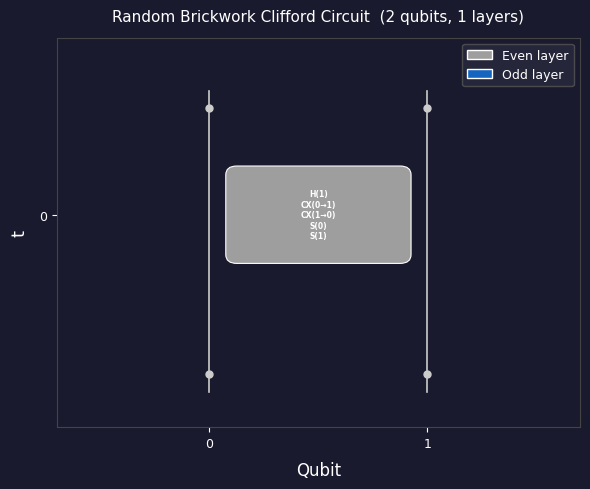

=== STABILIZER MATRIX (n x 2n binary) ===
Shape: (2, 4)  [rows=generators, cols=X_0..X_{n-1} | Z_0..Z_{n-1}]

     X0  X1  |  Z0  Z1
  ---------------
g0  | 1   1  |  0   0
g1  | 1   1  |  1   1



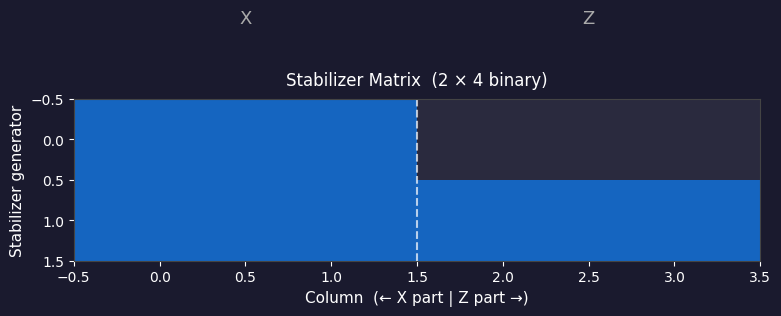

Stabilizer matrix shape: (2, 4)
Matrix dtype: uint8
Stabilizer shape: (2, 4), L: 2, n_cut: 1
Submatrix: 
 [[1 0]
 [1 1]] 

Rank: 2
Entanglement Entropy: 1


In [106]:
import stim
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch


# ── 1. CIRCUIT RUNNER ────────────────────────────────────────────────────────

def tableau_to_label(tableau):
    circuit = tableau.to_circuit(method="elimination")
    
    TWO_QUBIT_GATES = {"CX", "CNOT", "CZ", "SWAP", "ISWAP", "CY"}
    
    lines = []
    seen = set()
    
    for instruction in circuit:
        name = instruction.name
        if name == "TICK":
            continue
        
        targets = [t.value for t in instruction.targets_copy()]
        
        if name in TWO_QUBIT_GATES:
            # Targets come in pairs: (control, target), (control, target), ...
            for k in range(0, len(targets), 2):
                ctrl, tgt = targets[k], targets[k+1]
                entry = f"{name}({ctrl}→{tgt})"
                if entry not in seen:
                    seen.add(entry)
                    lines.append(entry)
        else:
            # Single-qubit gate — one target per application
            for t in targets:
                entry = f"{name}({t})"
                if entry not in seen:
                    seen.add(entry)
                    lines.append(entry)
    
    return "\n".join(lines) if lines else "I"


def random_brickwork_circuit(n_qubits, n_layers):
    """
    Runs random brickwork Clifford circuit.
    Returns simulator and gate log for visualization.
    
    gate_log: list of (layer, qubit_i, qubit_j, label) for every gate applied
    """
    sim = stim.TableauSimulator()
    sim.set_num_qubits(n_qubits)
    
    gate_log = []  # records (layer_idx, qubit_i, qubit_j, label)
    
    for layer in range(n_layers):
        start = layer % 2
        for i in range(start, n_qubits - 1, 2):
            gate = stim.Tableau.random(2)
            sim.do_tableau(gate, [i, i + 1])
            label = tableau_to_label(gate)
            gate_log.append((layer, i, i + 1, label))
    
    return sim, gate_log


# ── 2. STABILIZER BINARY MATRIX ──────────────────────────────────────────────

def get_stabilizer_matrix(sim, n_qubits):
    """
    Returns the stabilizer tableau as an (n x 2n) binary matrix.
    
    Columns 0..n-1      → X components (qubit 0 to n-1)
    Columns n..2n-1     → Z components (qubit 0 to n-1)
    """
    tableau = sim.current_inverse_tableau() ** -1
    x_part, z_part, _, _, _, _ = tableau.to_numpy()
    
    # x_part: shape (n, n) bool — x_part[i, j] = X component of generator i on qubit j
    # z_part: shape (n, n) bool
    binary_matrix = np.hstack([x_part, z_part]).astype(np.uint8)
    return binary_matrix


def print_stabilizer_matrix(matrix, n_qubits):
    """Pretty-prints the (n x 2n) binary stabilizer matrix."""
    n = n_qubits
    print("=== STABILIZER MATRIX (n x 2n binary) ===")
    print(f"Shape: {matrix.shape}  [rows=generators, cols=X_0..X_{{n-1}} | Z_0..Z_{{n-1}}]")
    print()
    
    # Header
    x_header = "  ".join([f"X{j}" for j in range(n)])
    z_header = "  ".join([f"Z{j}" for j in range(n)])
    print(f"     {x_header}  |  {z_header}")
    print("  " + "-" * (6 * n + 3))
    
    for i, row in enumerate(matrix):
        x_bits = "   ".join(map(str, row[:n]))
        z_bits = "   ".join(map(str, row[n:]))
        print(f"g{i:<2} | {x_bits}  |  {z_bits}")
    print()


# ── 3. CIRCUIT VISUALIZER ────────────────────────────────────────────────────

def plot_brickwork_circuit(n_qubits, n_layers, gate_log, figsize=None):
    """
    Plots the brickwork circuit matching the reference image:
    - Qubits on x-axis (labeled 0..n-1)
    - Time on y-axis (0 at bottom, n_layers at top)
    - Gray boxes = even-layer gates
    - Blue boxes = odd-layer gates
    - Qubit wires run vertically
    """
    if figsize is None:
        w = max(6, n_qubits * 0.9)
        h = max(5, n_layers * 0.9)
        figsize = (w, h)
    
    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor('#1a1a2e')
    ax.set_facecolor('#1a1a2e')
    
    # Color scheme matching reference image
    EVEN_COLOR  = '#9e9e9e'   # gray  — even layers
    ODD_COLOR   = '#1565C0'   # blue  — odd layers
    WIRE_COLOR  = '#cccccc'
    
    box_width  = 0.75   # spans 2 qubits minus a gap
    box_height = 0.45
    
    # ── Draw qubit wires (vertical lines) ────────────────────────────
    for q in range(n_qubits):
        ax.plot([q, q], [-0.5, n_layers + 0.2],
                color=WIRE_COLOR, linewidth=1.2, zorder=1)
        
        # Terminal dots at top and bottom
        ax.plot(q, -0.4,      'o', color=WIRE_COLOR, markersize=5, zorder=3)
        ax.plot(q, n_layers + 0.1, 'o', color=WIRE_COLOR, markersize=5, zorder=3)
    
    # ── Draw gate boxes ───────────────────────────────────────────────
    for (layer_idx, q_i, q_j, label) in gate_log:
        is_odd = (layer_idx % 2 == 1)
        color  = ODD_COLOR if is_odd else EVEN_COLOR
        
        y_center = layer_idx + 0.5
        x_left   = q_i + 0.5 - box_width / 2
        y_bottom = y_center - box_height / 2
        
        box = FancyBboxPatch(
            (x_left, y_bottom), box_width, box_height,
            boxstyle="round,pad=0.05",
            facecolor=color,
            edgecolor='white',
            linewidth=0.8,
            zorder=4
        )
        ax.add_patch(box)
        
        # Gate label centered on the box
        ax.text(
            q_i + 0.5, y_center, label,
            color='white', fontsize=5.5, fontweight='bold',
            ha='center', va='center', zorder=5,
            linespacing=1.2
        )
    
    # ── Axes formatting ───────────────────────────────────────────────
    ax.set_xlim(-0.7, n_qubits - 0.3)
    ax.set_ylim(-0.7, n_layers + 0.5)
    
    ax.set_xlabel("Qubit", color='white', fontsize=12, labelpad=8)
    ax.set_ylabel("t", color='white', fontsize=13, labelpad=8)
    
    ax.set_xticks(range(n_qubits))
    ax.set_xticklabels(range(n_qubits), color='white', fontsize=9)
    
    # Y ticks: show layer indices
    y_tick_step = max(1, n_layers // 10)
    y_ticks = list(range(0, n_layers, y_tick_step))
    ax.set_yticks([t + 0.5 for t in y_ticks])
    ax.set_yticklabels(y_ticks, color='white', fontsize=9)
    
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#444')
    
    # ── Legend ────────────────────────────────────────────────────────
    legend_elements = [
        mpatches.Patch(facecolor=EVEN_COLOR, edgecolor='white', label='Even layer'),
        mpatches.Patch(facecolor=ODD_COLOR,  edgecolor='white', label='Odd layer'),
    ]
    ax.legend(handles=legend_elements, loc='upper right',
              facecolor='#2a2a3e', edgecolor='#555', labelcolor='white',
              fontsize=9)
    
    ax.set_title(f"Random Brickwork Clifford Circuit  ({n_qubits} qubits, {n_layers} layers)",
                 color='white', fontsize=11, pad=12)
    
    plt.tight_layout()
    plt.show()


# ── 4. STABILIZER MATRIX HEATMAP ─────────────────────────────────────────────

def plot_stabilizer_matrix(matrix, n_qubits):
    """
    Plots the (n x 2n) binary stabilizer matrix as a heatmap.
    Left half = X components, right half = Z components.
    """
    n = n_qubits
    fig, ax = plt.subplots(figsize=(max(8, n * 0.25), max(4, n * 0.15)))
    fig.patch.set_facecolor('#1a1a2e')
    ax.set_facecolor('#1a1a2e')
    
    cmap = plt.cm.colors.ListedColormap(['#2a2a3e', '#1565C0'])
    ax.imshow(matrix, aspect='auto', cmap=cmap, interpolation='nearest',
              vmin=0, vmax=1)
    
    # Dividing line between X and Z halves
    ax.axvline(x=n - 0.5, color='white', linewidth=1.5, linestyle='--', alpha=0.7)
    
    # Labels
    ax.set_xlabel("Column  (← X part | Z part →)", color='white', fontsize=11)
    ax.set_ylabel("Stabilizer generator", color='white', fontsize=11)
    ax.set_title(f"Stabilizer Matrix  ({n} × {2*n} binary)",
                 color='white', fontsize=12, pad=10)
    
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#444')
    
    # X/Z region annotations
    ax.text(n / 2 - 0.5,       -1.5, "X", color='#aaa', fontsize=13,
            ha='center', va='center')
    ax.text(n + n / 2 - 0.5,   -1.5, "Z", color='#aaa', fontsize=13,
            ha='center', va='center')
    
    plt.tight_layout()
    plt.show()


# ── 5. MAIN ───────────────────────────────────────────────────────────────────

if __name__ == "__main__":
    N_QUBITS = 2
    N_LAYERS =1
    
    # Run circuit
    sim, gate_log = random_brickwork_circuit(N_QUBITS, N_LAYERS)
    
    # Plot circuit diagram
    plot_brickwork_circuit(N_QUBITS, N_LAYERS, gate_log)
    
    # Get and display stabilizer matrix
    stab_matrix = get_stabilizer_matrix(sim, N_QUBITS)
    print_stabilizer_matrix(stab_matrix, N_QUBITS)
    plot_stabilizer_matrix(stab_matrix, N_QUBITS)
    
    print(f"Stabilizer matrix shape: {stab_matrix.shape}")
    print(f"Matrix dtype: {stab_matrix.dtype}")

    print(f"Entanglement Entropy: {calculate_entropy(stab_matrix, n_cut=1)}")

In [107]:
import stim
import numpy as np

# ==========================================
# 1. PRE-COMPILE THE LEXICON
# ==========================================
all_tableaus = list(stim.Tableau.iter_all(2))
clifford_pool = [tab.to_circuit() for tab in all_tableaus]

# ==========================================
# 2. CIRCUIT GENERATOR AND MATRIX EXTRACTOR
# ==========================================

def get_binary_stabilizer_matrix(L, T):
    """
    1. Initializes a quantum state |00...0>
    2. Generates and applies T layers of random unitary brickwork
    3. Extracts and returns the final L x 2L binary stabilizer matrix
    """
    # Initialize the simulator
    sim = stim.TableauSimulator()
    
    # Evolve the state over T time steps
    for t in range(T):
        circuit = stim.Circuit()
        offset = t % 2
        
        # Build the entangling layer
        for i in range(offset, L - 1, 2):
            choice = np.random.randint(0, 11520)
            base_circ = clifford_pool[choice]
            
            for inst in base_circ:
                shifted_targets = [target.value + i for target in inst.targets_copy()]
                circuit.append(inst.name, shifted_targets)
                
        # Execute the layer on the quantum state
        sim.do(circuit)
        
    # Extract the final physical state
    tableau = sim.current_inverse_tableau() ** -1
    
    # Convert tableau to numpy arrays
    # _ ignores the X-destabilizers and sign bits which we don't need for entropy
    _, _, z2x, z2z, _, _ = tableau.to_numpy()
    
    # Stack the X and Z components to form the standard L x 2L check matrix
    # Cast to uint8 (or uint64 if you are feeding it directly into the bit-packer)
    binary_matrix = np.hstack([z2x.astype(np.uint8), z2z.astype(np.uint8)])
    
    return binary_matrix

# ==========================================
# TEST THE OUTPUT
# ==========================================


t1 = time.time()
final_matrix = get_binary_stabilizer_matrix(25, 25)
t2 = time.time()
print(f"Time taken for circuit generation and matrix extraction: {t2 - t1:.2f} seconds")
entropy = calculate_entropy(final_matrix, n_cut=12)
t3 = time.time()
print(f"Time taken for entropy calculation: {t3 - t2:.2f} seconds")
print(f"Entanglement Entropy: {entropy}")

Time taken for circuit generation and matrix extraction: 1.36 seconds
Stabilizer shape: (25, 50), L: 25, n_cut: 12
Submatrix: 
 [[0 1 1 1 1 1 0 1 1 0 1 1 1 0 1 1 1 1 1 1 0 1 1 0]
 [0 0 1 0 1 1 1 0 1 0 0 0 0 0 0 1 1 1 1 1 0 1 0 0]
 [1 1 1 0 0 0 0 1 1 1 0 1 0 0 0 1 0 0 0 1 0 0 0 0]
 [0 1 1 1 0 0 0 1 1 1 0 1 1 0 0 0 0 1 0 1 0 0 0 0]
 [1 0 1 0 1 0 0 1 0 1 0 1 0 0 1 1 0 1 1 1 0 1 0 1]
 [1 0 1 0 0 0 1 0 0 1 1 0 0 0 1 1 0 1 1 0 1 1 0 1]
 [1 1 0 0 0 1 1 0 1 1 1 1 1 1 1 1 1 0 0 0 1 0 0 1]
 [1 1 1 1 1 1 1 1 0 0 1 1 1 0 0 0 0 0 1 1 0 0 1 0]
 [0 1 0 0 0 1 0 0 1 1 0 1 1 1 0 0 1 0 0 1 1 1 1 0]
 [0 1 0 0 1 1 1 1 1 0 0 1 1 0 0 0 1 0 0 0 1 0 0 1]
 [0 0 0 0 0 0 1 1 0 1 0 1 0 0 0 0 0 0 0 0 1 0 1 1]
 [1 0 1 1 1 0 0 0 1 0 0 1 0 1 0 0 1 0 1 0 0 1 1 0]
 [0 0 1 1 0 1 1 1 0 1 1 1 1 1 1 1 1 0 0 0 1 0 1 0]
 [0 0 1 1 0 0 1 1 0 1 0 1 0 1 0 1 1 0 0 0 1 1 0 1]
 [0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 0]
 [0 0 1 0 1 1 0 1 0 1 0 0 0 0 1 1 1 0 0 1 0 0 0 1]
 [0 0 1 0 1 1 0 1 0 0 1 1 0 0 1 1 1 0 0 1 1 0 0 0]
 [0 0

In [108]:
import stim
import numpy as np

# ==========================================
# 1. PRE-COMPILE THE LEXICON
# ==========================================
all_tableaus = list(stim.Tableau.iter_all(2))
clifford_pool = [tab.to_circuit() for tab in all_tableaus]

# ==========================================
# 2. CIRCUIT GENERATOR AND MATRIX EXTRACTOR
# ==========================================

L, T = 100, 100

t4 = time.time()
sim = stim.TableauSimulator()

t5 = time.time()
print(f"Time taken for simulator initialization: {t5 - t4:.2f} seconds")
for t in range(T):
    circuit = stim.Circuit()
    offset = t % 2
    
    # Build the entangling layer
    for i in range(offset, L - 1, 2):
        choice = np.random.randint(0, 11520)
        base_circ = clifford_pool[choice]
        
        for inst in base_circ:
            shifted_targets = [target.value + i for target in inst.targets_copy()]
            circuit.append(inst.name, shifted_targets)
            
    # Execute the layer on the quantum 
    sim.do(circuit)
t6 = time.time()
print(f"Time taken for circuit generation and execution: {t6 - t5:.2f} seconds")
    
# Extract the final physical state
tableau = sim.current_inverse_tableau() ** -1

t7 = time.time()
print(f"Time taken for tableau extraction: {t7 - t6:.2f} seconds")

# Convert tableau to numpy arrays
# _ ignores the X-destabilizers and sign bits which we don't need for entropy
_, _, z2x, z2z, _, _ = tableau.to_numpy()

t8 = time.time()
print(f"Time taken for tableau to numpy conversion: {t8 - t7:.2f} seconds")

# Stack the X and Z components to form the standard L x 2L check matrix
# Cast to uint8 (or uint64 if you are feeding it directly into the bit-packer)
binary_matrix = np.hstack([z2x.astype(np.uint8), z2z.astype(np.uint8)])
t9 = time.time()
print(f"Time taken for binary matrix construction: {t9 - t8:.2f} seconds")


# ==========================================
# TEST THE OUTPUT
# ==========================================




t2 = time.time()
entropy = calculate_entropy(binary_matrix, n_cut=50)
t3 = time.time()
print(f"Time taken for entropy calculation: {t3 - t2:.2f} seconds")
print(f"Entanglement Entropy: {entropy}")

Time taken for simulator initialization: 0.00 seconds
Time taken for circuit generation and execution: 24.60 seconds
Time taken for tableau extraction: 0.01 seconds
Time taken for tableau to numpy conversion: 0.00 seconds
Time taken for binary matrix construction: 0.00 seconds
Stabilizer shape: (100, 200), L: 100, n_cut: 50
Submatrix: 
 [[1 1 0 ... 0 0 0]
 [1 0 1 ... 0 1 1]
 [1 0 1 ... 1 0 0]
 ...
 [0 0 0 ... 1 0 0]
 [0 0 0 ... 1 1 1]
 [0 0 0 ... 0 1 1]] 

Rank: 86
Time taken for entropy calculation: 0.00 seconds
Entanglement Entropy: 36
